# Namibia MSc Project — Data Preparation & Quality Assurance

**Purpose:** Load, inspect, and validate Copernicus GLO-30 DSM GeoTIFFs for Windhoek and Oshakati.

**Study areas:**
- Windhoek (WDH), Namibia
- Oshakati (OSH), Namibia

**Elevation data:** Copernicus DEM GLO-30 (2024_1) — Digital Surface Model

**CRS:** UTM 33S (EPSG:32733)

**Outputs:**
- Diagnostic plots (extent, histogram, spatial distribution)
- Baseline metadata log
- Validated rasters ready for hydrological analysis

---

## Setup & imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
from rasterio.plot import show, show_hist
from pathlib import Path

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")

✓ Imports successful


## Define data paths

In [2]:
# Project root and data directory
PROJECT_ROOT = Path('/Users/jacobsmacbookpro/Namibia_python')
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'

# Ensure processed directory exists
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# Input GeoTIFFs
## path_windhoek = DATA_RAW / 'copernicus_DEM_Namibia_windhoek.tif'
path_windhoek = DATA_RAW / 'copernicus_DEM_Namibia_small_WDH.tif'


##path_oshakati = DATA_RAW / 'copernicus_DEM_Namibia_cuvelai.tif'
path_oshakati = DATA_RAW / 'copernicus_DEM_Namibia_small_OSH.tif'



# Verify files exist
files_exist = {
    'Windhoek': path_windhoek.exists(),
    'Oshakati': path_oshakati.exists()
}

print("File existence check:")
for name, exists in files_exist.items():
    status = "✓" if exists else "✗"
    print(f"  {status} {name}: {exists}")

File existence check:
  ✓ Windhoek: True
  ✓ Oshakati: True


## Load and inspect GeoTIFFs

In [3]:
# Load Windhoek
with rasterio.open(path_windhoek) as src_wdh:
    dem_windhoek = src_wdh.read(1)
    meta_windhoek = src_wdh.meta.copy()
    profile_windhoek = src_wdh.profile.copy()

# Load Oshakati
with rasterio.open(path_oshakati) as src_osh:
    dem_oshakati = src_osh.read(1)
    meta_oshakati = src_osh.meta.copy()
    profile_oshakati = src_osh.profile.copy()

print("✓ GeoTIFFs loaded successfully")

✓ GeoTIFFs loaded successfully


## Metadata summary — Windhoek

In [4]:
print("\n" + "="*60)
print("WINDHOEK — Metadata")
print("="*60)

print(f"\nDimensions (rows, cols): {dem_windhoek.shape}")
print(f"CRS (native): {meta_windhoek['crs']}")
print(f"Pixel size (native): {meta_windhoek['transform'][0]:.6f}° (X) × {abs(meta_windhoek['transform'][4]):.6f}° (Y)")
print(f"Data type: {meta_windhoek['dtype']}")
print(f"NoData value: {meta_windhoek['nodata']}")
print(f"Number of bands: {meta_windhoek['count']}")

# Calculate bounds in native CRS (WGS 84)
transform = meta_windhoek['transform']
rows, cols = dem_windhoek.shape
ulx, uly = transform[2], transform[5]
lrx = ulx + transform[0] * cols
lry = uly + transform[4] * rows

print(f"\nExtent (WGS 84 — native):")
print(f"  Longitude: {ulx:.6f}° to {lrx:.6f}°")
print(f"  Latitude: {lry:.6f}° to {uly:.6f}°")
print(f"\n⚠ NOTE: Input raster is in WGS 84 (EPSG:4326)")
print(f"   Will be reprojected to UTM 33S (EPSG:32733) in preprocessing step.")


WINDHOEK — Metadata

Dimensions (rows, cols): (394, 644)
CRS (native): GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
Pixel size (native): 0.000269° (X) × 0.000269° (Y)
Data type: float32
NoData value: None
Number of bands: 1

Extent (WGS 84 — native):
  Longitude: 16.952557° to 17.126111°
  Latitude: -22.569094° to -22.462913°

⚠ NOTE: Input raster is in WGS 84 (EPSG:4326)
   Will be reprojected to UTM 33S (EPSG:32733) in preprocessing step.


ERROR 1: PROJ: internal_proj_identify: /Users/jacobsmacbookpro/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.


## Metadata summary — Oshakati

In [5]:
print("\n" + "="*60)
print("OSHAKATI — Metadata")
print("="*60)

print(f"\nDimensions (rows, cols): {dem_oshakati.shape}")
print(f"CRS (native): {meta_oshakati['crs']}")
print(f"Pixel size (native): {meta_oshakati['transform'][0]:.6f}° (X) × {abs(meta_oshakati['transform'][4]):.6f}° (Y)")
print(f"Data type: {meta_oshakati['dtype']}")
print(f"NoData value: {meta_oshakati['nodata']}")
print(f"Number of bands: {meta_oshakati['count']}")

# Calculate bounds in native CRS (WGS 84)
transform = meta_oshakati['transform']
rows, cols = dem_oshakati.shape
ulx, uly = transform[2], transform[5]
lrx = ulx + transform[0] * cols
lry = uly + transform[4] * rows

print(f"\nExtent (WGS 84 — native):")
print(f"  Longitude: {ulx:.6f}° to {lrx:.6f}°")
print(f"  Latitude: {lry:.6f}° to {uly:.6f}°")
print(f"\n⚠ NOTE: Input raster is in WGS 84 (EPSG:4326)")
print(f"   Will be reprojected to UTM 33S (EPSG:32733) in preprocessing step.")


OSHAKATI — Metadata

Dimensions (rows, cols): (248, 296)
CRS (native): GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
Pixel size (native): 0.000269° (X) × 0.000269° (Y)
Data type: float32
NoData value: None
Number of bands: 1

Extent (WGS 84 — native):
  Longitude: 15.636615° to 15.716385°
  Latitude: -17.803351° to -17.736517°

⚠ NOTE: Input raster is in WGS 84 (EPSG:4326)
   Will be reprojected to UTM 33S (EPSG:32733) in preprocessing step.


ERROR 1: PROJ: internal_proj_identify: /Users/jacobsmacbookpro/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.


## Elevation statistics

In [6]:
# Handle NoData — use np.isnan() for float data
nodata_wdh = meta_windhoek['nodata']
nodata_osh = meta_oshakati['nodata']

# For float32 data, use isnan instead of equality comparison
dem_wdh_valid = dem_windhoek[~np.isnan(dem_windhoek)]
dem_osh_valid = dem_oshakati[~np.isnan(dem_oshakati)]

# Calculate NaN counts and percentages
nan_count_wdh = np.isnan(dem_windhoek).sum()
nan_count_osh = np.isnan(dem_oshakati).sum()
nan_pct_wdh = (nan_count_wdh / dem_windhoek.size) * 100
nan_pct_osh = (nan_count_osh / dem_oshakati.size) * 100

print(f"\nDebug info:")
print(f"  Windhoek - total pixels: {dem_windhoek.size}, valid pixels: {dem_wdh_valid.size}")
print(f"  Oshakati - total pixels: {dem_oshakati.size}, valid pixels: {dem_osh_valid.size}")
print(f"  Windhoek - NoData value from metadata: {nodata_wdh}")
print(f"  Oshakati - NoData value from metadata: {nodata_osh}")

# Statistics
stats_df = pd.DataFrame({
    'Windhoek': [
        dem_wdh_valid.min(),
        dem_wdh_valid.max(),
        dem_wdh_valid.mean(),
        dem_wdh_valid.std(),
        np.percentile(dem_wdh_valid, 25),
        np.percentile(dem_wdh_valid, 50),
        np.percentile(dem_wdh_valid, 75),
        nan_count_wdh,
        nan_pct_wdh
    ],
    'Oshakati': [
        dem_osh_valid.min(),
        dem_osh_valid.max(),
        dem_osh_valid.mean(),
        dem_osh_valid.std(),
        np.percentile(dem_osh_valid, 25),
        np.percentile(dem_osh_valid, 50),
        np.percentile(dem_osh_valid, 75),
        nan_count_osh,
        nan_pct_osh
    ]
}, index=['Min (m)', 'Max (m)', 'Mean (m)', 'Std Dev (m)', 'Q1 (m)', 'Median (m)', 'Q3 (m)', 'NaN pixels', 'NaN %'])

print("\nElevation Statistics:")
# Format to avoid scientific notation
pd.options.display.float_format = '{:.2f}'.format
print(stats_df.to_string())

print(f"\nRelief (max - min):")
print(f"  Windhoek: {dem_wdh_valid.max() - dem_wdh_valid.min():.2f} m")
print(f"  Oshakati: {dem_osh_valid.max() - dem_osh_valid.min():.2f} m")



Debug info:
  Windhoek - total pixels: 253736, valid pixels: 246557
  Oshakati - total pixels: 73408, valid pixels: 72870
  Windhoek - NoData value from metadata: None
  Oshakati - NoData value from metadata: None

Elevation Statistics:
             Windhoek  Oshakati
Min (m)       1474.18   1087.50
Max (m)       2053.15   1105.44
Mean (m)      1633.72   1094.36
Std Dev (m)     77.99      1.45
Q1 (m)        1589.41   1093.25
Median (m)    1622.73   1094.10
Q3 (m)        1655.62   1095.34
NaN pixels    7179.00    538.00
NaN %            2.83      0.73

Relief (max - min):
  Windhoek: 578.97 m
  Oshakati: 17.93 m


## Visualization — Elevation histograms

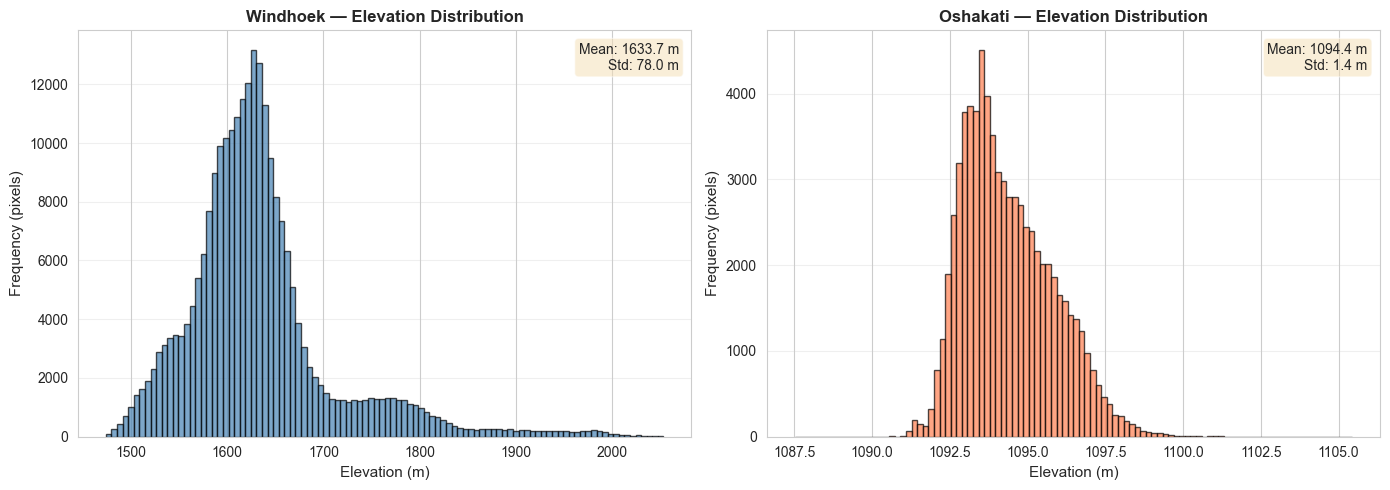


✓ Elevation histograms saved to: data/processed/01_elevation_histograms.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Windhoek histogram
axes[0].hist(dem_wdh_valid, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Elevation (m)', fontsize=11)
axes[0].set_ylabel('Frequency (pixels)', fontsize=11)
axes[0].set_title('Windhoek — Elevation Distribution', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].text(0.98, 0.97, f"Mean: {dem_wdh_valid.mean():.1f} m\nStd: {dem_wdh_valid.std():.1f} m",
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Oshakati histogram
axes[1].hist(dem_osh_valid, bins=100, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Elevation (m)', fontsize=11)
axes[1].set_ylabel('Frequency (pixels)', fontsize=11)
axes[1].set_title('Oshakati — Elevation Distribution', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].text(0.98, 0.97, f"Mean: {dem_osh_valid.mean():.1f} m\nStd: {dem_osh_valid.std():.1f} m",
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(DATA_PROCESSED / '01_elevation_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Elevation histograms saved to: data/processed/01_elevation_histograms.png")

## Visualization — Elevation maps (spatial distribution)

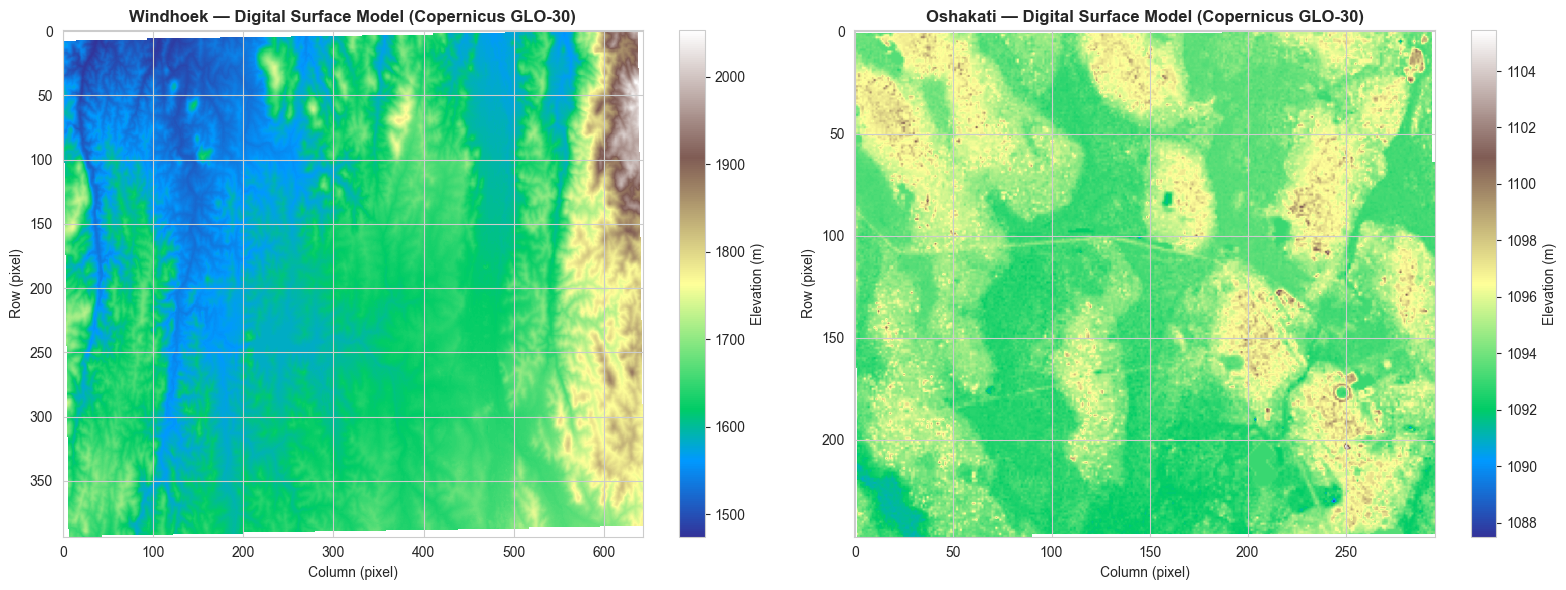


✓ Elevation maps saved to: data/processed/01_elevation_maps.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Windhoek elevation map
im1 = axes[0].imshow(dem_windhoek, cmap='terrain', aspect='auto')
axes[0].set_title('Windhoek — Digital Surface Model (Copernicus GLO-30)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Column (pixel)', fontsize=10)
axes[0].set_ylabel('Row (pixel)', fontsize=10)
cbar1 = plt.colorbar(im1, ax=axes[0], label='Elevation (m)')

# Oshakati elevation map
im2 = axes[1].imshow(dem_oshakati, cmap='terrain', aspect='auto')
axes[1].set_title('Oshakati — Digital Surface Model (Copernicus GLO-30)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Column (pixel)', fontsize=10)
axes[1].set_ylabel('Row (pixel)', fontsize=10)
cbar2 = plt.colorbar(im2, ax=axes[1], label='Elevation (m)')

plt.tight_layout()
plt.savefig(DATA_PROCESSED / '01_elevation_maps.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Elevation maps saved to: data/processed/01_elevation_maps.png")

## Quality assurance checks

In [9]:
print("\n" + "="*60)
print("Quality Assurance Checklist")
print("="*60)

checks = {
    'Windhoek': {
        '✓ CRS is WGS 84 (native)': 'WGS 84' in str(meta_windhoek['crs']),
        '✓ Data type is float32': meta_windhoek['dtype'] == 'float32',
        '✓ Reasonable elevation range': 1000 < dem_wdh_valid.mean() < 2500,
        '✓ Reasonable std dev': 10 < dem_wdh_valid.std() < 500,
        '✓ Single band': meta_windhoek['count'] == 1,
    },
    'Oshakati': {
        '✓ CRS is WGS 84 (native)': 'WGS 84' in str(meta_oshakati['crs']),
        '✓ Data type is float32': meta_oshakati['dtype'] == 'float32',
        '✓ Reasonable elevation range': 1000 < dem_osh_valid.mean() < 2500,
        '✓ Reasonable std dev': 10 < dem_osh_valid.std() < 500,
        '✓ Single band': meta_oshakati['count'] == 1,
    }
}

for location, tests in checks.items():
    print(f"\n{location}:")
    for test_name, result in tests.items():
        status = "PASS" if result else "FAIL"
        symbol = "✓" if result else "✗"
        print(f"  {symbol} {test_name}: {status}")

print("\n" + "="*60)


Quality Assurance Checklist

Windhoek:
  ✓ ✓ CRS is WGS 84 (native): PASS
  ✓ ✓ Data type is float32: PASS
  ✓ ✓ Reasonable elevation range: PASS
  ✓ ✓ Reasonable std dev: PASS
  ✓ ✓ Single band: PASS

Oshakati:
  ✓ ✓ CRS is WGS 84 (native): PASS
  ✓ ✓ Data type is float32: PASS
  ✓ ✓ Reasonable elevation range: PASS
  ✗ ✓ Reasonable std dev: FAIL
  ✓ ✓ Single band: PASS



ERROR 1: PROJ: internal_proj_identify: /Users/jacobsmacbookpro/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/jacobsmacbookpro/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.


## Summary & next steps

In [10]:
print("\n" + "="*60)
print("DATA PREP & QA — SUMMARY")
print("="*60)

print("""
✓ Copernicus GLO-30 GeoTIFFs loaded and validated
✓ Input CRS: WGS 84 (EPSG:4326)
✓ Target CRS: UTM 33S (EPSG:32733) — will reproject in next notebook
✓ Elevation statistics computed
✓ Diagnostic visualizations created

KEY OBSERVATIONS:
  • Windhoek: More varied terrain (relief {:.0f} m), smaller extent
  • Oshakati: Much flatter (relief {:.0f} m), larger extent (justified for watershed context)
  • Both datasets are ready for preprocessing & projection

CRITICAL NEXT STEPS:
  1. Proceed to: 02_Preprocessing_Reprojection.ipynb
  2. Reproject both rasters from WGS 84 to UTM 33S
  3. Resample to consistent pixel size (~30 m)
  4. Handle NoData values
  5. Then proceed to terrain derivatives (slope, aspect, flow direction, etc.)

ASSUMPTIONS DOCUMENTED:
  • Copernicus GLO-30 is treated as a Digital Surface Model (DSM)
  • No DTM/DSM comparison available
  • Study extent = full raster extent (settlement overlay comes later)
  • Input rasters are in WGS 84 — reprojection is mandatory for D8 flow analysis

""".format(
    dem_wdh_valid.max() - dem_wdh_valid.min(),
    dem_osh_valid.max() - dem_osh_valid.min()
))

print("="*60)


DATA PREP & QA — SUMMARY

✓ Copernicus GLO-30 GeoTIFFs loaded and validated
✓ Input CRS: WGS 84 (EPSG:4326)
✓ Target CRS: UTM 33S (EPSG:32733) — will reproject in next notebook
✓ Elevation statistics computed
✓ Diagnostic visualizations created

KEY OBSERVATIONS:
  • Windhoek: More varied terrain (relief 579 m), smaller extent
  • Oshakati: Much flatter (relief 18 m), larger extent (justified for watershed context)
  • Both datasets are ready for preprocessing & projection

CRITICAL NEXT STEPS:
  1. Proceed to: 02_Preprocessing_Reprojection.ipynb
  2. Reproject both rasters from WGS 84 to UTM 33S
  3. Resample to consistent pixel size (~30 m)
  4. Handle NoData values
  5. Then proceed to terrain derivatives (slope, aspect, flow direction, etc.)

ASSUMPTIONS DOCUMENTED:
  • Copernicus GLO-30 is treated as a Digital Surface Model (DSM)
  • No DTM/DSM comparison available
  • Study extent = full raster extent (settlement overlay comes later)
  • Input rasters are in WGS 84 — reprojectio

## Save validated DEMs for later use

*(Optional: save processed versions if needed)*

In [11]:
# Note: We'll keep the original GeoTIFFs as-is.
# Processed/derivative rasters will be saved in subsequent notebooks.
print("\n✓ Data preparation complete. Ready to proceed to terrain analysis.")


✓ Data preparation complete. Ready to proceed to terrain analysis.
